# MACHINE LEARNING - Clustering Project
**Etudiants** : Louis-Gabriel BROSSIER | Victor LOUX | Hoang-Triet NGUYEN

## Introduction
L'hiver approche, les soirées s'allongent, et notre backlog Steam ne va clairement pas se trier tout seul. On a donc besoin d'analyser un dataset de jeux et d'utiliser du clustering pour repérer les pépites parfaites pour hiberner intelligemment.

### Notre jeu de données


*   C'est quoi le dataset ?

Ce dataset a été créé avec Steam store page scraping et Steam Games Scraper repository, qui collecte des données à l'aide de l'API Steam et Steam Spy. Elle est à jour jusqu'à mars 2025. Ce dataset nous permet d'avoir une vue globale sur un grand nombre de features pour chacun des jeux du Steam Store.

*   Lister tous les features

 Voici toutes les features que nous avons selectionnés : -appid -name - release_date -required_age -price - dlc_count -metacritic_score -achievements -recommendations -categories -positive -negative -median_playtime_forever -peak_ccu -pct_pos_total

*   Afficher 10 premiers lignes
*   Plotter la distribution des features

### Notre objectives


## Prétraitement des données


<Axes: xlabel='positive', ylabel='median_playtime_forever'>

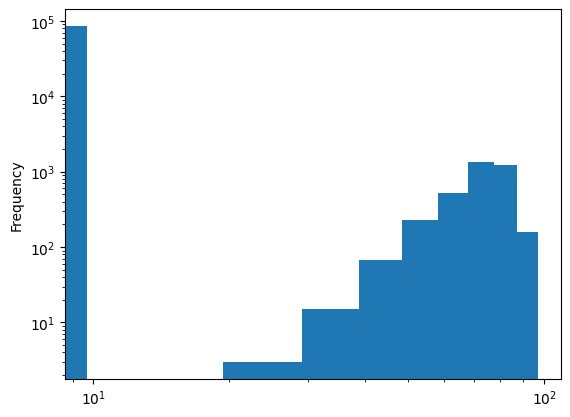

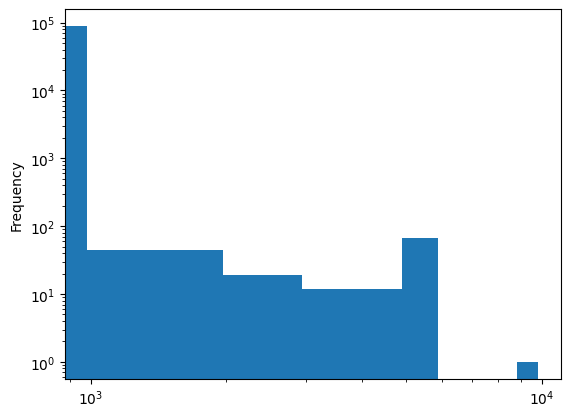

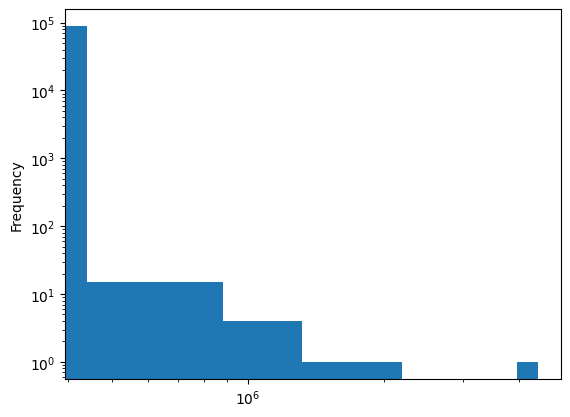

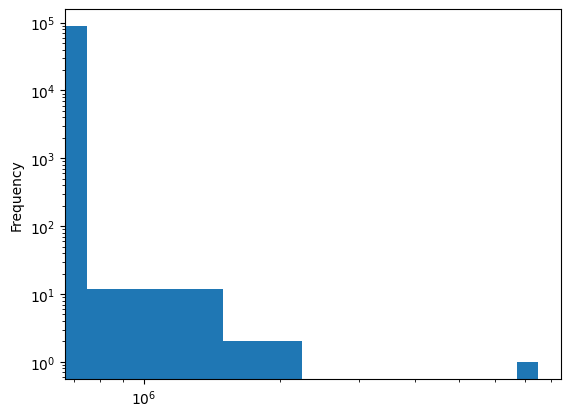

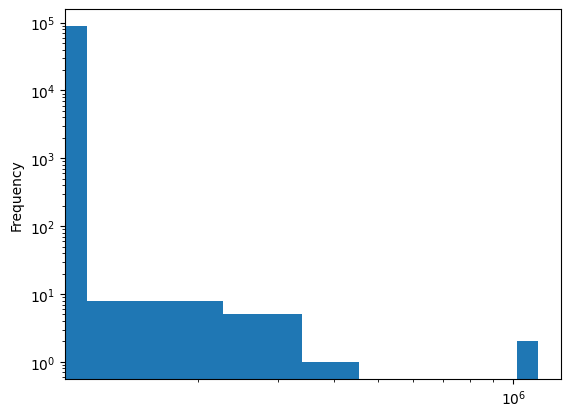

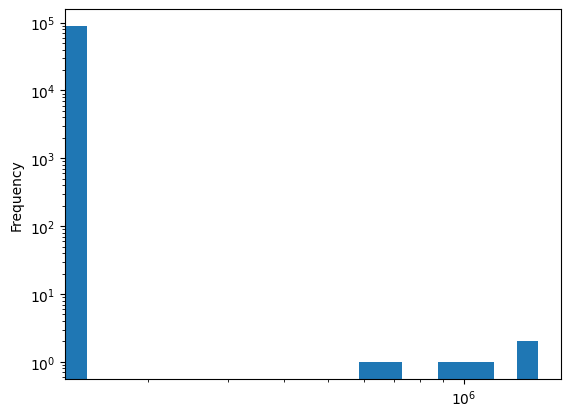

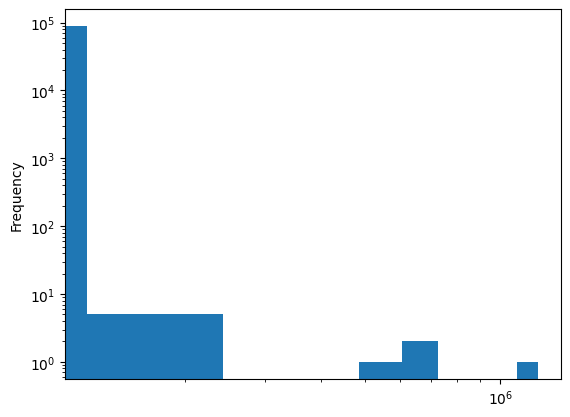

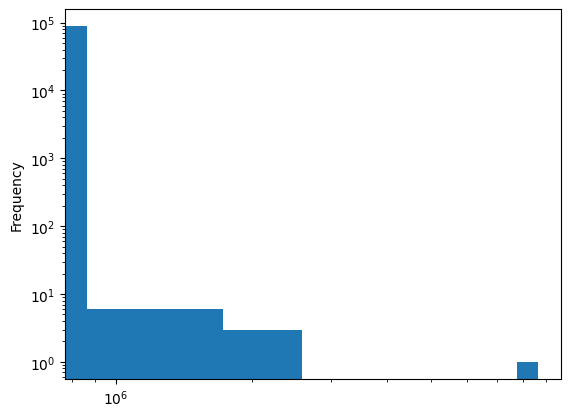

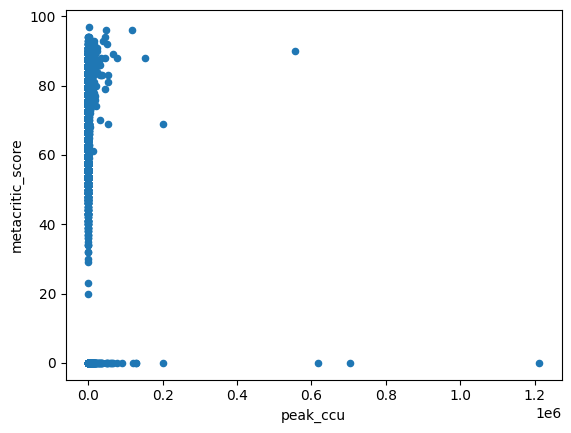

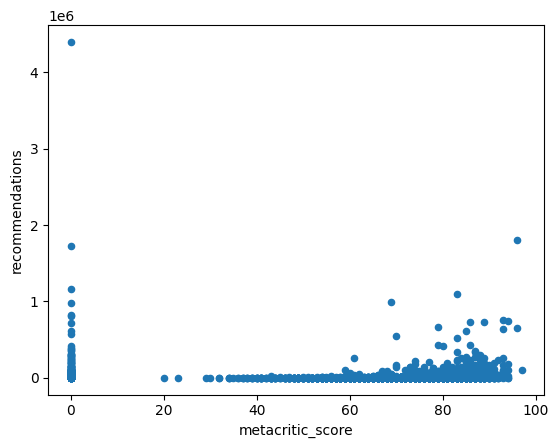

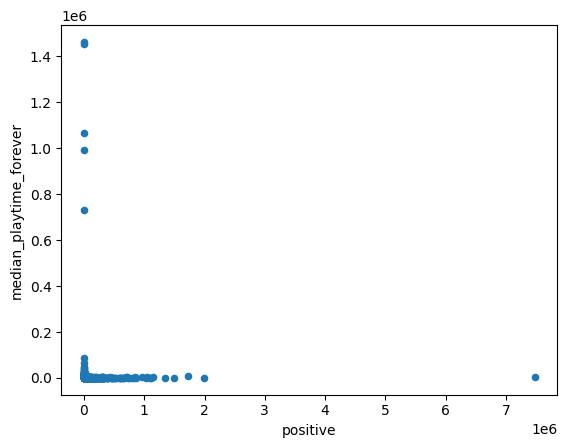

In [2]:
#importation de la librairie
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./dataset/Steam_Games_2025.csv")


#we look at the distributions in general of our data :
# print(df.describe(include='all'))

#for the columns with numbers, we can plot the histograms
#df.hist(column='appid')
list=['metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']

#histogrammes
for x in list:
  plt.figure()
  df[x].plot.hist(loglog=True)
#même en affichant les données sous l'échelle logarithmique, on observe déjà des pics au niveau de 0 pour les données manquantes(le dataset n'est pas complet)

#covariance & correlation
df2=df[['metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']]
df2.corr() 
#on observe qu'il y a qlq redondances dans notre jeux de données, les catégories recommendations, positive et num_reviews_total ont une correlation au dessus de 0.9.

df.plot.scatter(x='peak_ccu',y='metacritic_score')
df.plot.scatter(x='metacritic_score',y='recommendations')
df.plot.scatter(x='positive',y='median_playtime_forever')
#en testant qlq combinaisons de catégories en x et y (en évitant de prendre des catégories trop redondantes), 
# on observe que les données ne se regroupe pas bien, se répartissant plus selon l'absence de données que formant des clusters cohérents



In [3]:
#we search for how much features are missing

missing = df.eq(0).sum()
lenght= len(df)
print(missing)
print("lenght total du data set =",lenght)

#on observe que beaucoup de données sont manquante sur ce dataset, en particulier sur les petits jeux qui représentent la majorité des sorties steam.

appid                          0
name                           0
release_date                   0
required_age               88589
price                      14160
dlc_count                  75388
metacritic_score           86071
achievements               41090
recommendations            72881
categories                     0
positive                   19425
negative                   30396
median_playtime_forever    81608
peak_ccu                   70698
pct_pos_total                 18
num_reviews_total              0
dtype: int64
lenght total du data set = 89618


In [4]:
## Supprimer 'appid' du dataset
if ('appid' in df.columns):
    df = df.drop(columns=['appid'])

## Transformer 'release_date' en format POSIX (timestamp) en secondes
df['release_date'] = pd.to_datetime(df['release_date']).astype(int) / 10**9


## Extraire 'single_player' et 'multi_player' de la colonne 'categories'

def extract_category(df: pd.DataFrame, categories_name: str) -> int:
    return 1 if categories_name and df.find(categories_name) != -1 else 0
df['single_player'] = df['categories'].apply(extract_category, args=('Single-player',))
df['multi_player'] = df['categories'].apply(extract_category, args=('Multi-player',))
df = df.drop(columns=['categories'])
df.head(10)

,name,release_date,required_age,price,dlc_count,metacritic_score,achievements,recommendations,positive,negative,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player
0,Counter-Strike 2,1.345507e+09,0,0.00,1,0,1,4401572,7480813,1135108,5174,1212356,86,8632939,0,1
1,PUBG: BATTLEGROUNDS,1.513814e+09,0,0.00,0,0,37,1732007,1487960,1024436,0,616738,59,2513842,0,1
2,Dota 2,1.373328e+09,0,0.00,2,90,0,14337,1998462,451338,898,555977,81,2452595,0,1
3,Grand Theft Auto V Legacy,1.428883e+09,17,0.00,0,96,77,1803063,1719950,250012,7101,117698,87,1803832,1,1
4,Tom Clancy's Rainbow Six® Siege,1.448928e+09,17,3.99,9,0,0,1165929,1152763,218446,2434,89916,84,1168020,1,1
5,Team Fortress 2,1.191974e+09,0,0.00,1,92,520,41587,1025633,120619,0,50817,89,1146642,0,1
6,Terraria,1.305504e+09,0,9.99,2,83,115,1098792,1344773,34460,0,30516,97,1102434,1,1
7,Rust,1.518048e+09,0,39.99,4,69,92,992825,1043708,152272,3675,200902,87,993856,0,1
8,Garry's Mod,1.164758e+09,0,5.99,0,0,29,984713,1106689,36727,1173,32384,96,985010,1,1
9,Apex Legends™,1.604448e+09,0,0.00,0,88,12,1548,660150,322363,667,151844,67,983230,0,1


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

[[ 0.00000000e+00  8.09451715e-08  0.00000000e+00 ...  6.98794728e-01
   0.00000000e+00  8.09451715e-08]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  6.98205684e-01
   0.00000000e+00  2.77744458e-07]
 [ 0.00000000e+00  6.16565015e-07  2.77454257e-05 ...  7.56092136e-01
   0.00000000e+00  3.08282507e-07]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -3.53553391e-01
   3.53553391e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -2.93105191e-02
   2.93105191e-02  2.93105191e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -6.62266179e-02
   6.62266179e-02  6.62266179e-02]]


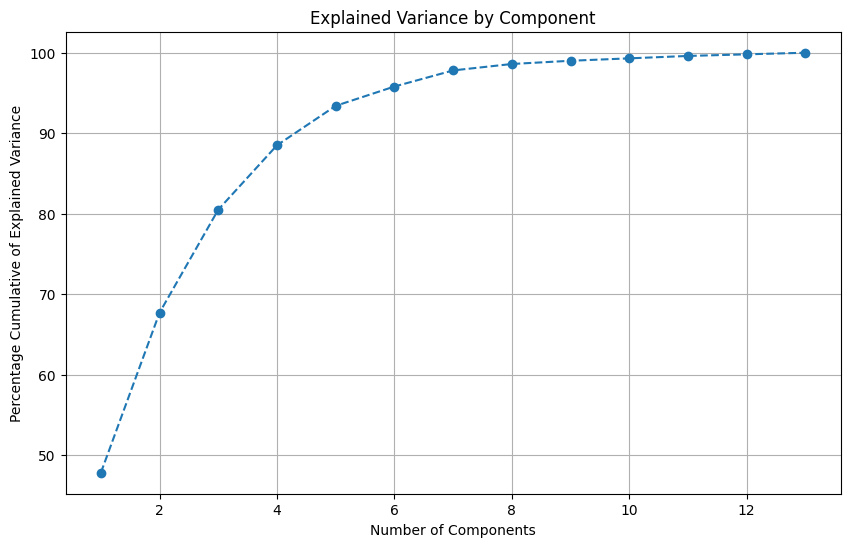

In [12]:
from sklearn.preprocessing import Normalizer

data1 = df.drop(columns=['name', 'price','release_date'])


normal_values = Normalizer().fit_transform(data1.values)
print(normal_values)
pca = PCA()
pca.fit(normal_values)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

On observe qu'on peut garder 100% de la variation à partir de 6 features, on se fixe un seuil de 90%, on gardera 5 sections.

In [13]:
pca = PCA(n_components = 5)
pca.fit(normal_values)
scores_pca = pca.transform(normal_values) 
#on réalise une PCA à 5 sections puis on stock le résultat

In [ ]:
# import numpy as np
# num_cols = [
#     'required_age',
#     'dlc_count',
#     'metacritic_score',
#     'achievements',
#     'median_playtime_forever',
#     'single_player',
#     'multi_player'
# ]
# log_cols = [
#     'recommendations',
#     'positive',
#     'negative',
#     'peak_ccu'
# ]
# drop_cols = [
#     'appid',
#     'name',
#     'price',
# ]
# df[log_cols] = df[log_cols].fillna(0)
# df[log_cols] = np.log1p(df[log_cols])

# cols_to_scale = num_cols + log_cols   # tes colonnes numériques + log

# # calcul des moyennes et écarts types
# means = df[cols_to_scale].mean()
# stds  = df[cols_to_scale].std()   

# # normalisation "standard"
# df = (df[cols_to_scale] - means) / stds

# # smatrice numpy pour le clustering :
# X_scaled = df.values
# df.head(10)

,required_age,dlc_count,metacritic_score,achievements,median_playtime_forever,single_player,multi_player,recommendations,positive,negative,peak_ccu
0,-0.106412,0.026343,-0.200981,-0.119541,0.574476,-4.021357,2.115691,5.421524,5.496547,6.197496,11.237581
1,-0.106412,-0.038795,-0.200981,0.100559,-0.013031,-4.021357,2.115691,5.062773,4.819589,6.145190,10.677481
2,-0.106412,0.091481,6.029394,-0.125654,0.088937,-4.021357,2.115691,3.218734,4.943237,5.727255,10.591530
3,9.745268,-0.038795,6.444753,0.345114,0.793286,0.248670,2.115691,5.078238,4.880325,5.426068,9.304888
4,9.745268,0.547451,-0.200981,-0.125654,0.263350,0.248670,2.115691,4.910544,4.712594,5.357251,9.081765
5,-0.106412,0.026343,6.167847,3.053560,-0.013031,-4.021357,2.115691,3.628342,4.663612,5.054436,8.608877
6,-0.106412,0.091481,5.544809,0.577441,-0.013031,0.248670,2.115691,4.887732,4.777176,4.415655,8.186266
7,-0.106412,0.221758,4.575640,0.436822,0.404265,-4.021357,2.115691,4.848724,4.670935,5.173252,9.747988
8,-0.106412,-0.038795,-0.200981,0.051648,0.120163,0.248670,2.115691,4.845569,4.695496,4.448140,8.235500
9,-0.106412,-0.038795,5.890941,-0.052288,0.062707,-4.021357,2.115691,2.362780,4.478919,5.555663,9.515983
